In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Komal Verma\Desktop\data analyyst\retail_sales-analysis\data\Superstore sales dataset.csv", encoding="latin1")

In [6]:
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ï»¿Row ID      9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.shape

(9994, 21)

In [9]:
df.isnull().sum()

ï»¿Row ID        0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [14]:
conn = sqlite3.connect("superstore.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created")

Database Created


In [15]:
query = """

SELECT *
FROM sales
LIMIT 5

"""

pd.read_sql_query(query,conn)

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
query1 = """
SELECT Region,
       ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

result1 = pd.read_sql_query(query1, conn)

result1

,Region,Total_Sales
0,West,725457.82
1,East,678781.24
2,Central,501239.89
3,South,391721.91


FileNotFoundError: [Errno 2] No such file or directory: 'images/region_sales.png'

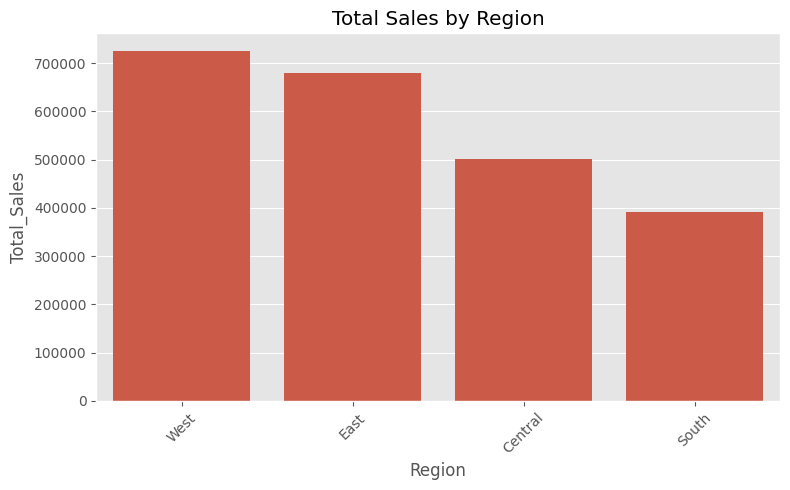

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=result1, x="Region", y="Total_Sales")
plt.title("Total Sales by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/region_sales.png")
plt.show()

In [19]:
query2 = """
SELECT "Product Name",
       ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Profit DESC
LIMIT 10;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,Product Name,Total_Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04
2,Hewlett Packard LaserJet 3310 Copier,6983.88
3,Canon PC1060 Personal Laser Copier,4570.93
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98
5,Ativa V4110MDD Micro-Cut Shredder,3772.95
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28
8,Ibico EPK-21 Electric Binding System,3345.28
9,Zebra ZM400 Thermal Label Printer,3343.54


FileNotFoundError: [Errno 2] No such file or directory: 'images/top_products.png'

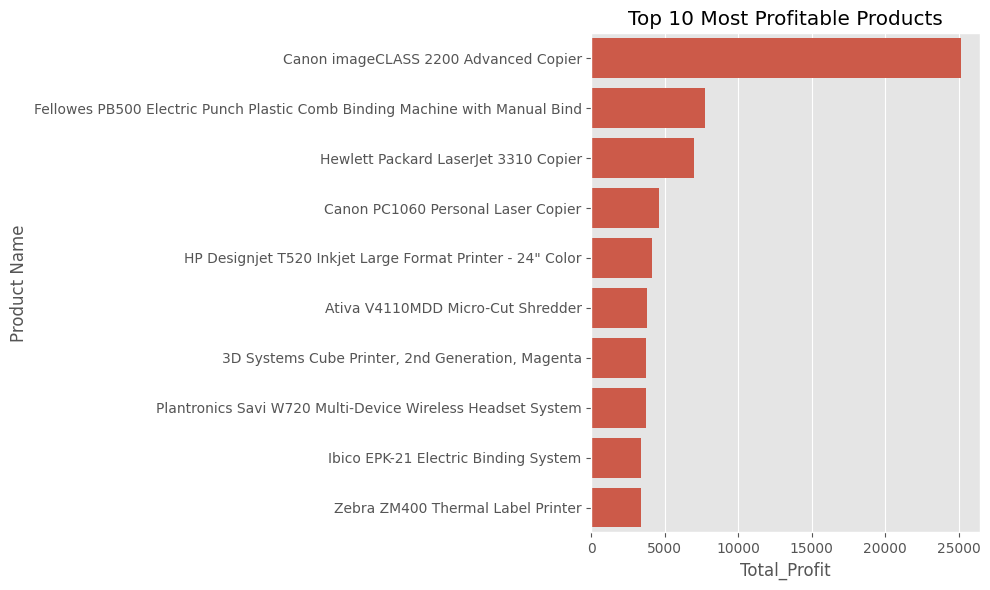

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(data=result2, x="Total_Profit", y="Product Name")
plt.title("Top 10 Most Profitable Products")
plt.tight_layout()
plt.savefig("images/top_products.png")
plt.show()

In [21]:
query3 = """
SELECT
strftime('%Y-%m',"Order Date") AS Month,
ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

result3 = pd.read_sql_query(query3, conn)
result3

,Month,Total_Sales
0,2014-01,14236.90
1,2014-02,4519.89
2,2014-03,55691.01
3,2014-04,28295.35
4,2014-05,23648.29
5,2014-06,34595.13
6,2014-07,33946.39
7,2014-08,27909.47
8,2014-09,81777.35
9,2014-10,31453.39


FileNotFoundError: [Errno 2] No such file or directory: 'images/monthly_sales.png'

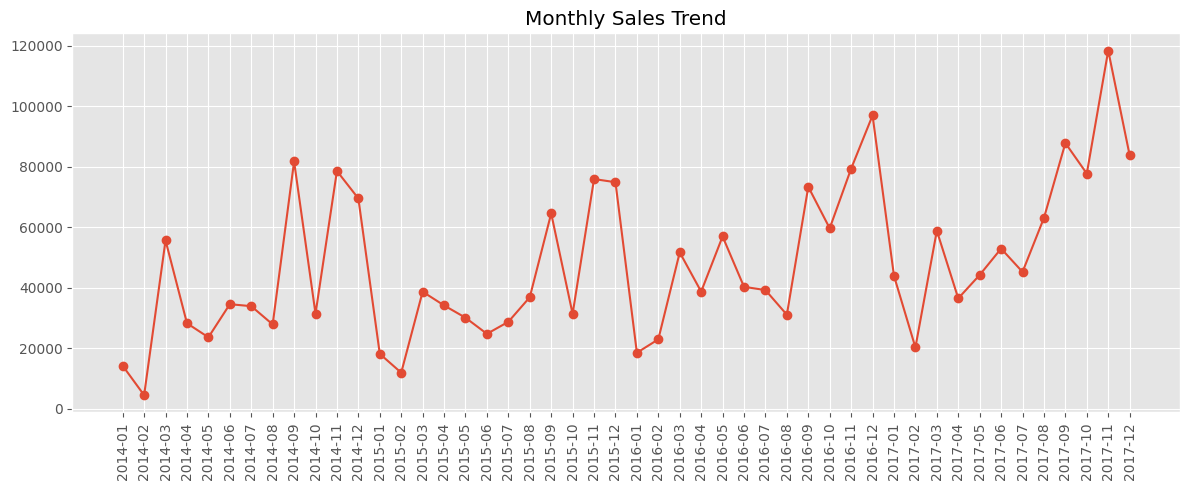

In [22]:
plt.figure(figsize=(12,5))
plt.plot(result3["Month"], result3["Total_Sales"], marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.savefig("images/monthly_sales.png")
plt.show()


In [23]:
query4 = """
SELECT Segment,
ROUND(AVG(Sales),2) AS Avg_Order_Value
FROM sales
GROUP BY Segment
ORDER BY Avg_Order_Value DESC;
"""

result4 = pd.read_sql_query(query4, conn)
result4

,Segment,Avg_Order_Value
0,Home Office,240.97
1,Corporate,233.82
2,Consumer,223.73


FileNotFoundError: [Errno 2] No such file or directory: 'images/segment_order_value.png'

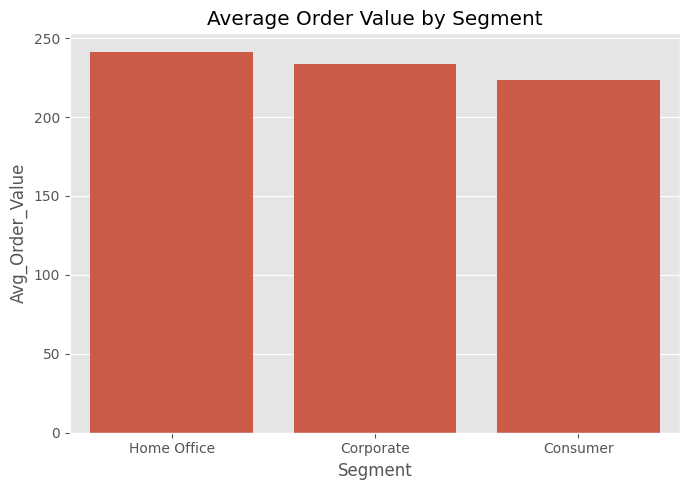

In [24]:
plt.figure(figsize=(7,5))
sns.barplot(data=result4, x="Segment", y="Avg_Order_Value")
plt.title("Average Order Value by Segment")
plt.tight_layout()
plt.savefig("images/segment_order_value.png")
plt.show()

In [25]:
query5 = """
SELECT
"Order Date",
Sales,
SUM(Sales) OVER(
ORDER BY "Order Date"
) AS Running_Total
FROM sales
LIMIT 100;
"""

result5 = pd.read_sql_query(query5, conn)
result5

,Order Date,Sales,Running_Total
0,2014-01-03 00:00:00,16.448,16.448
1,2014-01-04 00:00:00,11.784,304.508
2,2014-01-04 00:00:00,272.736,304.508
3,2014-01-04 00:00:00,3.540,304.508
4,2014-01-05 00:00:00,19.536,324.044
...,...,...,...
95,2014-02-11 00:00:00,234.450,17717.729
96,2014-02-11 00:00:00,1256.220,17717.729
97,2014-02-11 00:00:00,17.460,17717.729
98,2014-02-11 00:00:00,60.890,17717.729


FileNotFoundError: [Errno 2] No such file or directory: 'images/running_total.png'

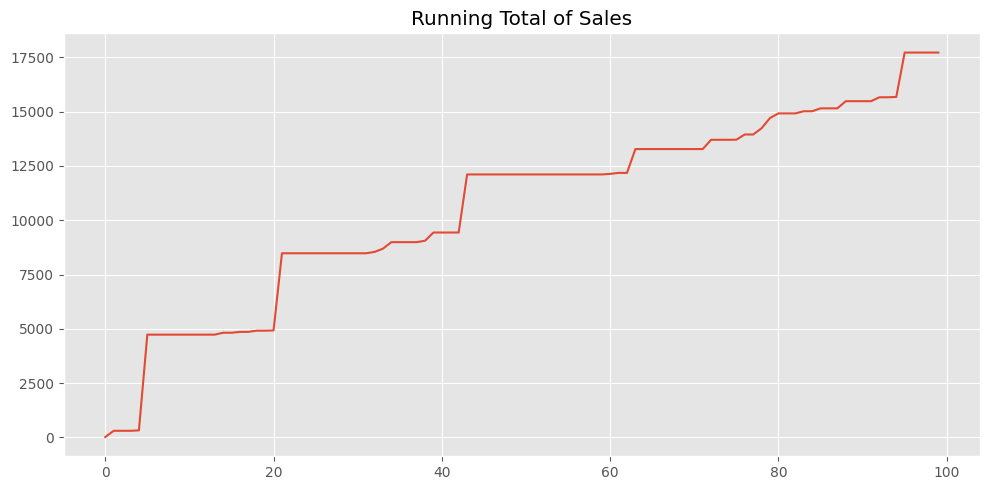

In [26]:
plt.figure(figsize=(10,5))
plt.plot(result5["Running_Total"])
plt.title("Running Total of Sales")
plt.tight_layout()
plt.savefig("images/running_total.png")
plt.show()

In [27]:
query6 = """
SELECT
"Product Name",
ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY "Product Name"
HAVING SUM(Profit)<0
ORDER BY Total_Profit;
"""

result6 = pd.read_sql_query(query6, conn)
result6

,Product Name,Total_Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.97
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.97
2,Cubify CubeX 3D Printer Triple Head Print,-3839.99
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.12
4,Bush Advantage Collection Racetrack Conference...,-1934.40
...,...,...
297,Rubber Band Ball,-0.30
298,"Acco PRESSTEX Data Binder with Storage Hooks, ...",-0.16
299,"Avery Trapezoid Extra Heavy Duty 4"" Binders",-0.00
300,Global Super Steno Chair,-0.00


FileNotFoundError: [Errno 2] No such file or directory: 'images/loss_products.png'

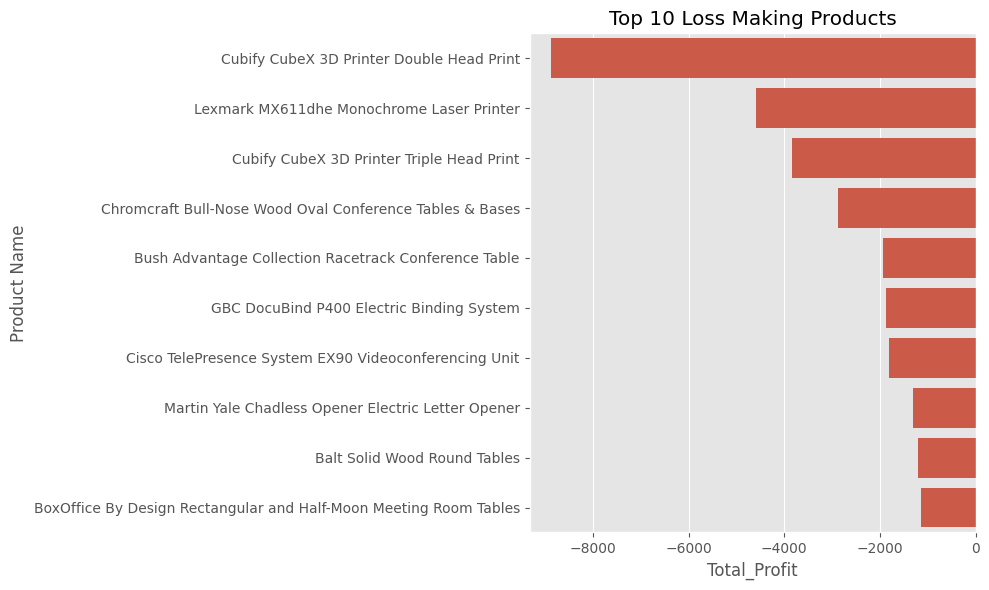

In [28]:
top_loss = result6.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_loss, x="Total_Profit", y="Product Name")
plt.title("Top 10 Loss Making Products")
plt.tight_layout()
plt.savefig("images/loss_products.png")
plt.show()

In [29]:
query7 = """
SELECT Category,
ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

result7 = pd.read_sql_query(query7, conn)
result7

,Category,Total_Profit
0,Technology,145454.95
1,Office Supplies,122490.80
2,Furniture,18451.27


FileNotFoundError: [Errno 2] No such file or directory: 'images/profit_category.png'

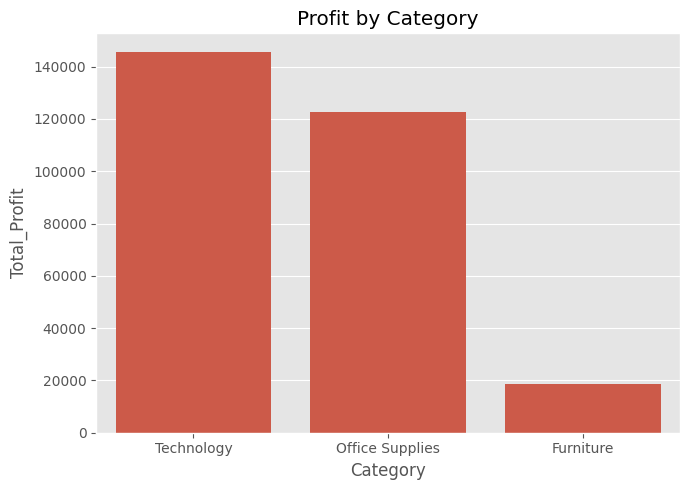

In [30]:
plt.figure(figsize=(7,5))
sns.barplot(data=result7, x="Category", y="Total_Profit")
plt.title("Profit by Category")
plt.tight_layout()
plt.savefig("images/profit_category.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'images/correlation_heatmap.png'

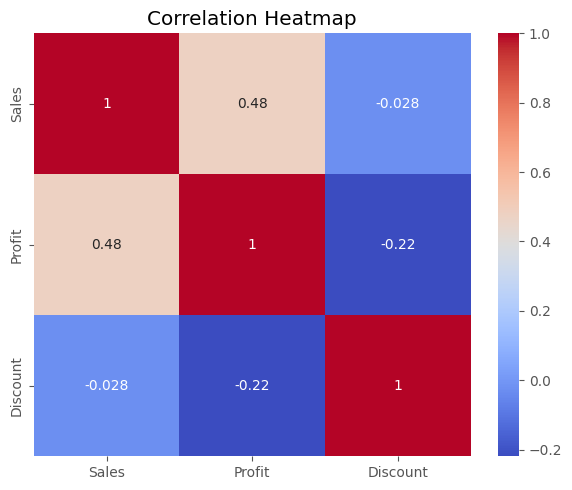

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["Sales","Profit","Discount"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'images/discount_profit.png'

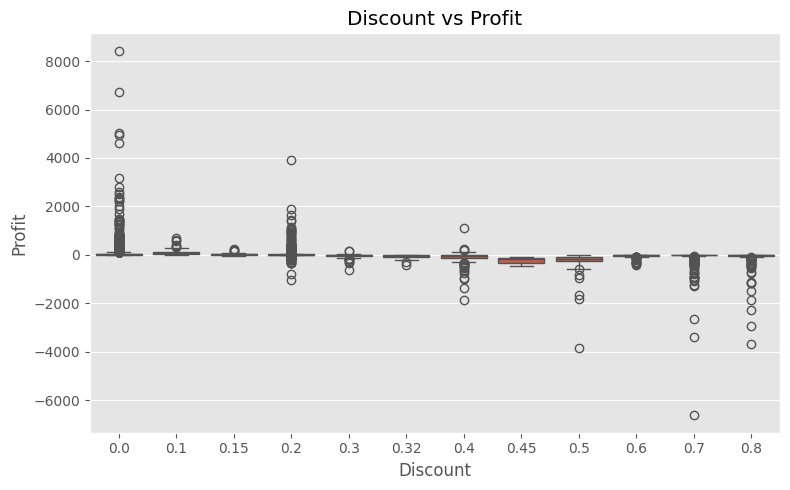

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Discount"], y=df["Profit"])
plt.title("Discount vs Profit")
plt.tight_layout()
plt.savefig("images/discount_profit.png")
plt.show()

In [34]:
df.describe()

,ï»¿Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [35]:
df.dtypes

ï»¿Row ID                 int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [36]:
df.isnull().sum()

ï»¿Row ID        0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
# Key Insights

- The West region generated the highest overall sales.
- Technology products contributed the highest profits.
- Furniture showed comparatively lower profit margins.
- Higher discounts generally resulted in lower profits.
- Consumer segment generated the highest revenue.
- A few products consistently incurred losses.
- Sales showed seasonal peaks during the year.

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
conn.close()

print("SQLite Connection Closed Successfully")

SQLite Connection Closed Successfully
